# Phân tích mối quan hệ giữa ngành hàng và hiệu quả bán (So sánh giữa các sản phẩm trong danh mục)

## Thành viên: Phương

### Bàn luận:
- Dựa trên kết quả EDA, hệ thống danh mục được tổ chức theo cấu trúc phân cấp gồm 5 root category, mỗi root bao gồm nhiều middle category, và mỗi middle tiếp tục phân thành nhiều leaf category. Điều này dẫn đến không gian phân tích rộng và phức tạp trong từng danh mục.

- Để đảm bảo các insight mang tính khách quan và có giá trị, trước tiên xây dựng một dashboard tổng quan nhằm cung cấp cái nhìn cơ bản về từng root category. Trên cơ sở đó, các câu hỏi phân tích trọng tâm sẽ được xác định.

- Trong phần này, trọng tâm là khám phá mối quan hệ giữa danh mục và các sản phẩm bên trong, đặc biệt xoay quanh hai chỉ số chính: doanh thu và số lượng bán ra, nhằm phản ánh mức độ phát triển và tiềm năng của từng danh mục.

### Mục tiêu phân tích:
1. **Câu hỏi 1**: Với từng Danh mục gốc, danh mục nào đang phát triển mạnh nhất (doanh thu, số lượt bán) đối với các sản phẩm được lên bán trên sàn TMĐT Tiki (trong giai đoạn 2021-2025)?
2. **Câu hỏi 2**: Trong các danh mục có doanh thu cao đã xác định ở Câu 1, sự tăng trưởng này đến từ việc toàn bộ sản phẩm cùng đóng góp tương đối đồng đều, hay bị chi phối bởi một số ít sản phẩm nổi bật? NNếu tồn tại các sản phẩm này, đâu là những đặc điểm chung đứng sau hiệu suất vượt trội của chúng (trong giai đoạn 2021-2025)?



In [13]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import matplotlib.cm as cm
from matplotlib.ticker import FuncFormatter

import seaborn as sns

import os
import warnings
warnings.filterwarnings('ignore')

# Display configuration
plt.rcParams['figure.figsize'] = (16, 10)
plt.rcParams['font.size'] = 10
plt.rcParams['font.family'] = 'sans-serif'
sns.set_style('whitegrid')
sns.set_theme(style="whitegrid")
pd.set_option('display.max_columns', None)


# Create output directory if not exists
output_dir = '../output'
os.makedirs(output_dir, exist_ok=True)

## 1. Tải Dữ liệu

In [14]:
# Load 4 common data tables following team standards
df_store = pd.read_csv('../../data/stores.csv')
df_category = pd.read_csv('../../data/categories.csv')
df_product = pd.read_csv('../../data/products.csv')
df_review = pd.read_csv('../../data/reviews.csv')

print("Data Size:")
print(f"Stores: {df_store.shape}")
print(f"Categories: {df_category.shape}")
print(f"Products: {df_product.shape}")
print(f"Reviews: {df_review.shape}")

Data Size:
Stores: (1446, 5)
Categories: (496, 4)
Products: (55883, 14)
Reviews: (158126, 9)


## 2. Khám phá Tổng quan về các danh mục

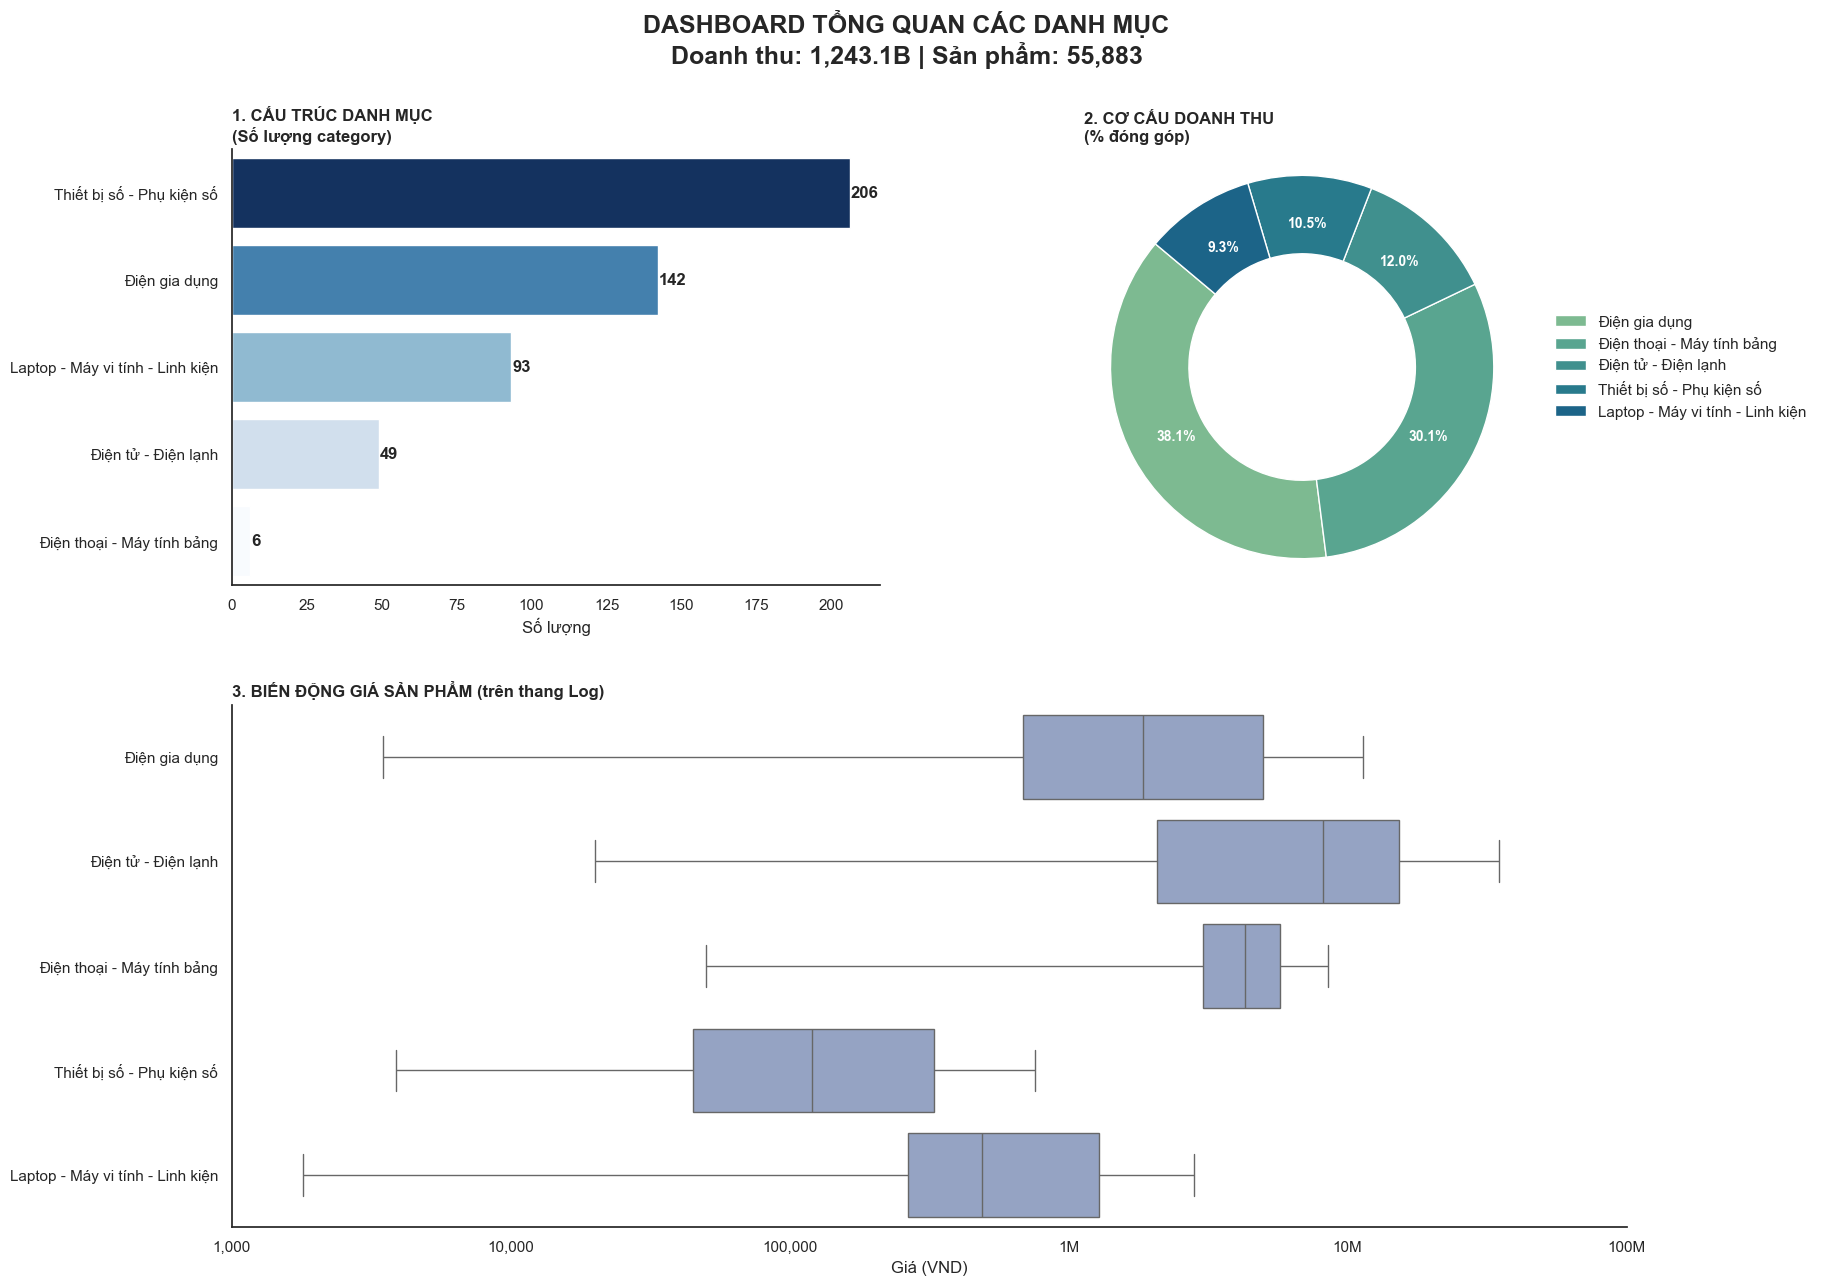

In [15]:
df_category_dashboard = df_category.copy()

df_category_dashboard["category_id"] = df_category_dashboard["category_id"].astype(str)
df_category_dashboard["parent_category"] = df_category_dashboard["parent_category"].astype("string")

name_to_id = dict(zip(
    df_category_dashboard["category_name"],
    df_category_dashboard["category_id"]
))

df_category_dashboard["parent_id"] = df_category_dashboard["parent_category"].map(name_to_id)

ROOT_IDS = set([
    "1882",  # Điện gia dụng
    "1789",  # Điện thoại - Máy tính bảng
    "4221",  # Điện tử - Điện lạnh
    "1846",  # Laptop - Máy vi tính - Linh kiện
    "1815",  # Thiết bị số - Phụ kiện số
])

parent_map = dict(zip(
    df_category_dashboard["category_id"],
    df_category_dashboard["parent_id"]
))

def find_root(cat_id):
    visited = set()
    
    while True:
        if cat_id in ROOT_IDS:
            return cat_id
        
        parent = parent_map.get(cat_id)
        
        if pd.isna(parent) or parent is None:
            return cat_id
        
        if parent in visited:
            return cat_id
        
        visited.add(cat_id)
        cat_id = parent

df_category_dashboard["root_category_id"] = df_category_dashboard["category_id"].apply(find_root)

id_to_name = dict(zip(
    df_category_dashboard["category_id"],
    df_category_dashboard["category_name"]
))

df_category_dashboard["root_category_name"] = df_category_dashboard["root_category_id"].map(id_to_name)

df_main = df_product.copy()
df_main["category_id"] = df_main["category_id"].astype(str)

cat_to_root = dict(zip(
    df_category_dashboard["category_id"],
    df_category_dashboard["root_category_name"]
))

df_main["root_category_name"] = df_main["category_id"].map(cat_to_root)

# ======================
# 2. BUILD DF_MAIN
# ======================
df_main = df_product.copy()
df_main["category_id"] = df_main["category_id"].astype(str)

# map category → root
cat_to_root = dict(zip(
    df_category_dashboard["category_id"],
    df_category_dashboard["root_category_name"]
))

df_main["root_category_name"] = df_main["category_id"].map(cat_to_root)

# ⚠️ fallback nếu map fail (rất quan trọng)
df_main["root_category_name"] = df_main["root_category_name"].fillna("Unknown")

# ======================
# 3. CLEAN NUMERIC
# ======================
df_main["price"] = pd.to_numeric(df_main["price"], errors="coerce").fillna(0)
df_main["sold_count"] = pd.to_numeric(df_main["sold_count"], errors="coerce").fillna(0)

# revenue
df_main["revenue"] = df_main["price"] * df_main["sold_count"]

# ======================
# 4. STYLE
# ======================
plt.rcParams['font.family'] = 'sans-serif'
sns.set_theme(style="white", palette="crest")

fig = plt.figure(figsize=(18, 14))
gs = fig.add_gridspec(2, 2, height_ratios=[1, 1.2], wspace=0.15, hspace=0.25)

def format_money(x, pos):
    if x >= 1_000_000_000: return f'{x / 1_000_000_000:,.1f}B'
    if x >= 1_000_000: return f'{x / 1_000_000:,.0f}M'
    return f'{x:,.0f}'

# ======================
# FILTER TOP 5 ROOT CATEGORY
# ======================
top5_roots = (
    df_main.groupby("root_category_name")["revenue"]
    .sum()
    .sort_values(ascending=False)
    .head(5)
    .index
)

df_main_top5 = df_main[df_main["root_category_name"].isin(top5_roots)]
df_category_top5 = df_category_dashboard[
    df_category_dashboard["root_category_name"].isin(top5_roots)
]

# bar
ax1 = fig.add_subplot(gs[0, 0])

sub_cat_count = (
    df_category_top5
    .groupby("root_category_name")["category_id"]
    .count()
    .sort_values(ascending=False)
)

norm = plt.Normalize(sub_cat_count.min(), sub_cat_count.max())
colors = cm.Blues(norm(sub_cat_count.values))

sns.barplot(
    x=sub_cat_count.values,
    y=sub_cat_count.index,
    palette=colors,
    ax=ax1
)

ax1.set_title('1. CẤU TRÚC DANH MỤC\n(Số lượng category)', loc='left', fontweight='bold')
ax1.set_xlabel('Số lượng')
ax1.set_ylabel('')

for i, v in enumerate(sub_cat_count.values):
    ax1.text(v + 0.5, i, f'{int(v)}', va='center', fontweight='bold')

sns.despine(ax=ax1)

# donut
ax2 = fig.add_subplot(gs[0, 1])

revenue_by_root = (
    df_main_top5.groupby("root_category_name")["revenue"]
    .sum()
    .sort_values(ascending=False)
)

wedges, texts, autotexts = ax2.pie(
    revenue_by_root.values,
    autopct='%1.1f%%',
    startangle=140,
    pctdistance=0.75,
    radius=1.1,
    wedgeprops={'width': 0.45, 'edgecolor': 'w'}
)

ax2.legend(
    wedges,
    revenue_by_root.index,
    loc="center left",
    bbox_to_anchor=(1.05, 0.5),
    frameon=False
)

plt.setp(autotexts, size=10, weight="bold", color="white")

ax2.set_title('2. CƠ CẤU DOANH THU\n(% đóng góp)', loc='left', fontweight='bold')

#boxplot
ax3 = fig.add_subplot(gs[1, :])

top_roots = (
    df_main["root_category_name"]
    .value_counts()
    .head(5)
    .index
)

df_box = df_main_top5[
    df_main_top5["price"] > 0
]

sns.boxplot(
    data=df_box,
    x="price",
    y="root_category_name",
    showfliers=False,
    color="#8da0cb", 
    ax=ax3
)

ax3.set_xscale("log")

ticks = [1e3, 1e4, 1e5, 1e6, 1e7, 1e8]
ax3.set_xticks(ticks)
ax3.xaxis.set_major_formatter(FuncFormatter(format_money))

ax3.set_title('3. BIẾN ĐỘNG GIÁ SẢN PHẨM (trên thang Log)', loc='left', fontweight='bold')
ax3.set_xlabel('Giá (VND)')
ax3.set_ylabel('')

sns.despine(ax=ax3)

# ======================
# TITLE
# ======================
total_rev = df_main["revenue"].sum()

fig.suptitle(
    f"DASHBOARD TỔNG QUAN CÁC DANH MỤC\n"
    f"Doanh thu: {format_money(total_rev, None)} | Sản phẩm: {len(df_main):,}",
    fontsize=18,
    fontweight='bold'
)

plt.show()

## 3. Câu hỏi 1: 

### Với từng Danh mục gốc, danh mục nào đang phát triển mạnh nhất (doanh thu, số lượt bán) đối với các sản phẩm được lên bán trên sàn TMĐT Tiki (trong giai đoạn 2021-2025)?

Triển khai:
- Dựa trên 5 danh mục gốc đã quan sát ở mục 2. Xác định danh mục đang phát triển mạnh nhất thông qua 2 yếu tố doanh thu và lượt bán. 
- Sử dụng biến `sold_count` để phân tích số lượng bán. Tạo biến `revenue` = `price` * `sold_count` để phân tích doanh thu.
- Để trực quan hóa, so sánh các danh mục này em sẽ dùng Bar chart. Vì đây là dữ liệu đơn giản, biểu đồ chỉ cần làm rõ sự chênh lệch giữa các danh mục.

Giai đoạn phân tích: 2021 - 2025
- Em muốn làm nổi bật xu hướng mới nhất của thị trường. Các sản phẩn xuất hiện trước đó đã được bán ra và duy trì trong thời gian dài, sẽ không đảm bảo được insight về xu hướng hiện tại (do sử dụng doanh thu và lượt bán để phân tích). 
- Chọn chu kỳ 5 năm: 
- Giai đoạn 2021–2025 (sau ảnh hưởng của Covid-19) đánh dấu nhiều biến động và đổi mới trong nền kinh tế nói chung và lĩnh vực thương mại điện tử nói riêng. 

In [16]:
df_product['created_at'] = pd.to_datetime(df_product['created_at'], errors='coerce')
df_q1_product = df_product[(df_product['created_at'].dt.year >= 2021) & (df_product['created_at'].dt.year <= 2025)].copy()

df_q1_category = df_category.copy()

df_q1_product["revenue"] = df_q1_product["sold_count"] * df_q1_product["price"]

root_ids = set(df_category[df_category["parent_category"].isna()]["category_id"])

# mapping
parent_map = dict(zip(df_q1_category["category_id"], df_q1_category["parent_category"]))
name_to_id = dict(zip(df_q1_category["category_name"], df_q1_category["category_id"]))
id_to_name = dict(zip(df_q1_category["category_id"], df_q1_category["category_name"]))

cat_to_root = {}

for cat_id in df_q1_category["category_id"]:
    current = cat_id
    
    while pd.notna(parent_map[current]):
        parent_name = parent_map[current]
        current = name_to_id[parent_name]
    
    cat_to_root[cat_id] = current

df_q1_product["root_category_id"] = df_q1_product["category_id"].map(cat_to_root)

cat_name_map = df_category.set_index("category_id")["category_name"]

df_q1_product["category_name"] = df_q1_product["category_id"].map(cat_name_map)
df_q1_product["root_category_name"] = df_q1_product["root_category_id"].map(cat_name_map)

df_group = (
    df_q1_product
    .groupby(["root_category_name", "category_name"])["revenue"]
    .sum()
    .reset_index()
)

df_group["rank"] = df_group.groupby("root_category_name")["revenue"] \
                          .rank(method="first", ascending=False)

top5_each_root = df_group[df_group["rank"] <= 5] \
                    .sort_values(["root_category_name", "rank"])

df_group["pct_in_root"] = df_group["revenue"] / df_group.groupby("root_category_name")["revenue"].transform("sum")



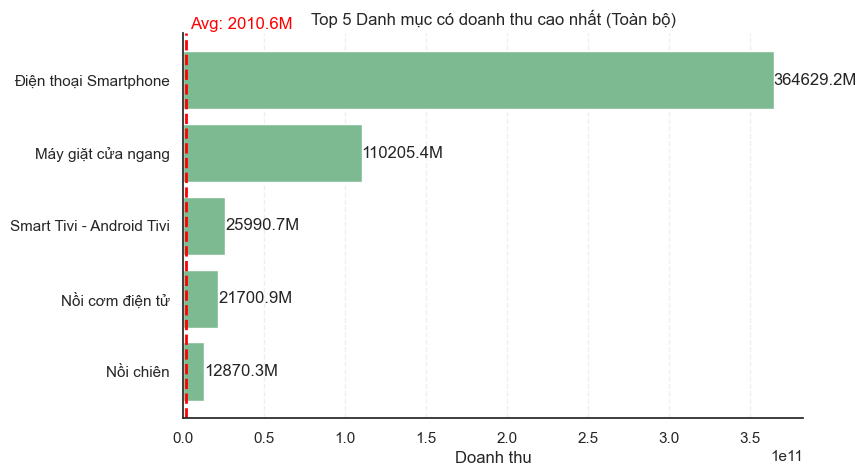

In [17]:
#top5 all
top5_all = (
    df_group
    .groupby("category_name")["revenue"]
    .sum()
    .reset_index()
    .sort_values(by="revenue", ascending=False)
    .head(5)
)

# average revenue (all)
avg_all = df_group.groupby("category_name")["revenue"].sum().mean()

# top5 each root
top5_each_root = df_group[df_group["rank"] <= 5] \
                    .sort_values(["root_category_name", "rank"])

# average revenue (each root)
avg_each_root = (
    df_group
    .groupby("root_category_name")["revenue"]
    .mean()
    .reset_index(name="avg_revenue")
)


plt.figure(figsize=(8,5))

plt.barh(top5_all["category_name"], top5_all["revenue"])
plt.gca().invert_yaxis()

for i, v in enumerate(top5_all["revenue"]):
    plt.text(v, i, f"{v/1e6:.1f}M", va='center')

plt.axvline(x=avg_all, color='red', linestyle='--', linewidth=2)
offset = avg_all * 1

plt.text(
    avg_all + offset, 
    -0.7, 
    f"Avg: {avg_all/1e6:.1f}M", 
    color='red'
)

ax = plt.gca()

for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)
plt.grid(axis='x', linestyle='--', alpha=0.3)
plt.title("Top 5 Danh mục có doanh thu cao nhất (Toàn bộ)")
plt.xlabel("Doanh thu")

plt.show()

### Quan sát

- Danh mục **Điện thoại Smartphone** vượt trội so với các danh mục còn lại, trở thành nhóm có doanh thu cao nhất trong mảng công nghệ trên sàn Tiki.  
- Các danh mục tiếp theo lần lượt là  **máy giặt cửa ngang**, **Smart Tivi - Android Tivi**, **nồi cơm điện tử**, **nồi chiên**.  
- Mặc dù doanh thu của từng danh mục phía sau đều thấp hơn đáng kể (dưới 1/3 so với Điện thoại Smartphone), nhưng có đến **2/5 danh mục trong Top 5 thuộc nhóm Điện gia dụng**. Điều này cho thấy nhu cầu đối với các sản phẩm gia dụng chiếm vai trò quan trọng trong hành vi mua sắm của người dùng trên nền tảng.

### Phân tích

- Phân tích bước đầu cho thấy **sự chênh lệch doanh thu giữa các danh mục là rất lớn**, phản ánh mức độ tập trung cao vào một số danh mục chủ lực, đặc biệt là Điện thoại Smartphone. Khi so sánh doanh thu của danh mục này (~364.6 tỷ) với **mức doanh thu trung bình (~2.0 tỷ)**, có thể thấy khoảng cách vượt trội rõ rệt.  
- Tuy nhiên, bên cạnh danh mục dẫn đầu, sự xuất hiện của nhiều danh mục thuộc **Điện gia dụng trong Top 5** cho thấy đây là nhóm ngành có **độ phủ nhu cầu rộng và ổn định**, đóng góp đáng kể vào tổng doanh thu dù không có một sản phẩm đơn lẻ chi phối tuyệt đối.  
- Những quan sát này cho thấy dữ liệu doanh thu theo danh mục chứa đựng nhiều thông tin giá trị, đặc biệt trong việc **xác định danh mục chủ lực và nhóm nhu cầu tiềm năng**. Tuy vậy, các kết luận hiện tại mới chỉ phản ánh bức tranh tổng quan.  
- Do đó, cần tiếp tục đi sâu phân tích ở cấp độ **từng danh mục gốc (root category)** nhằm làm rõ cấu trúc bên trong: liệu doanh thu được phân bổ đồng đều hay tập trung vào một số nhóm cụ thể, từ đó cung cấp cơ sở vững chắc hơn cho các đánh giá tiếp theo.

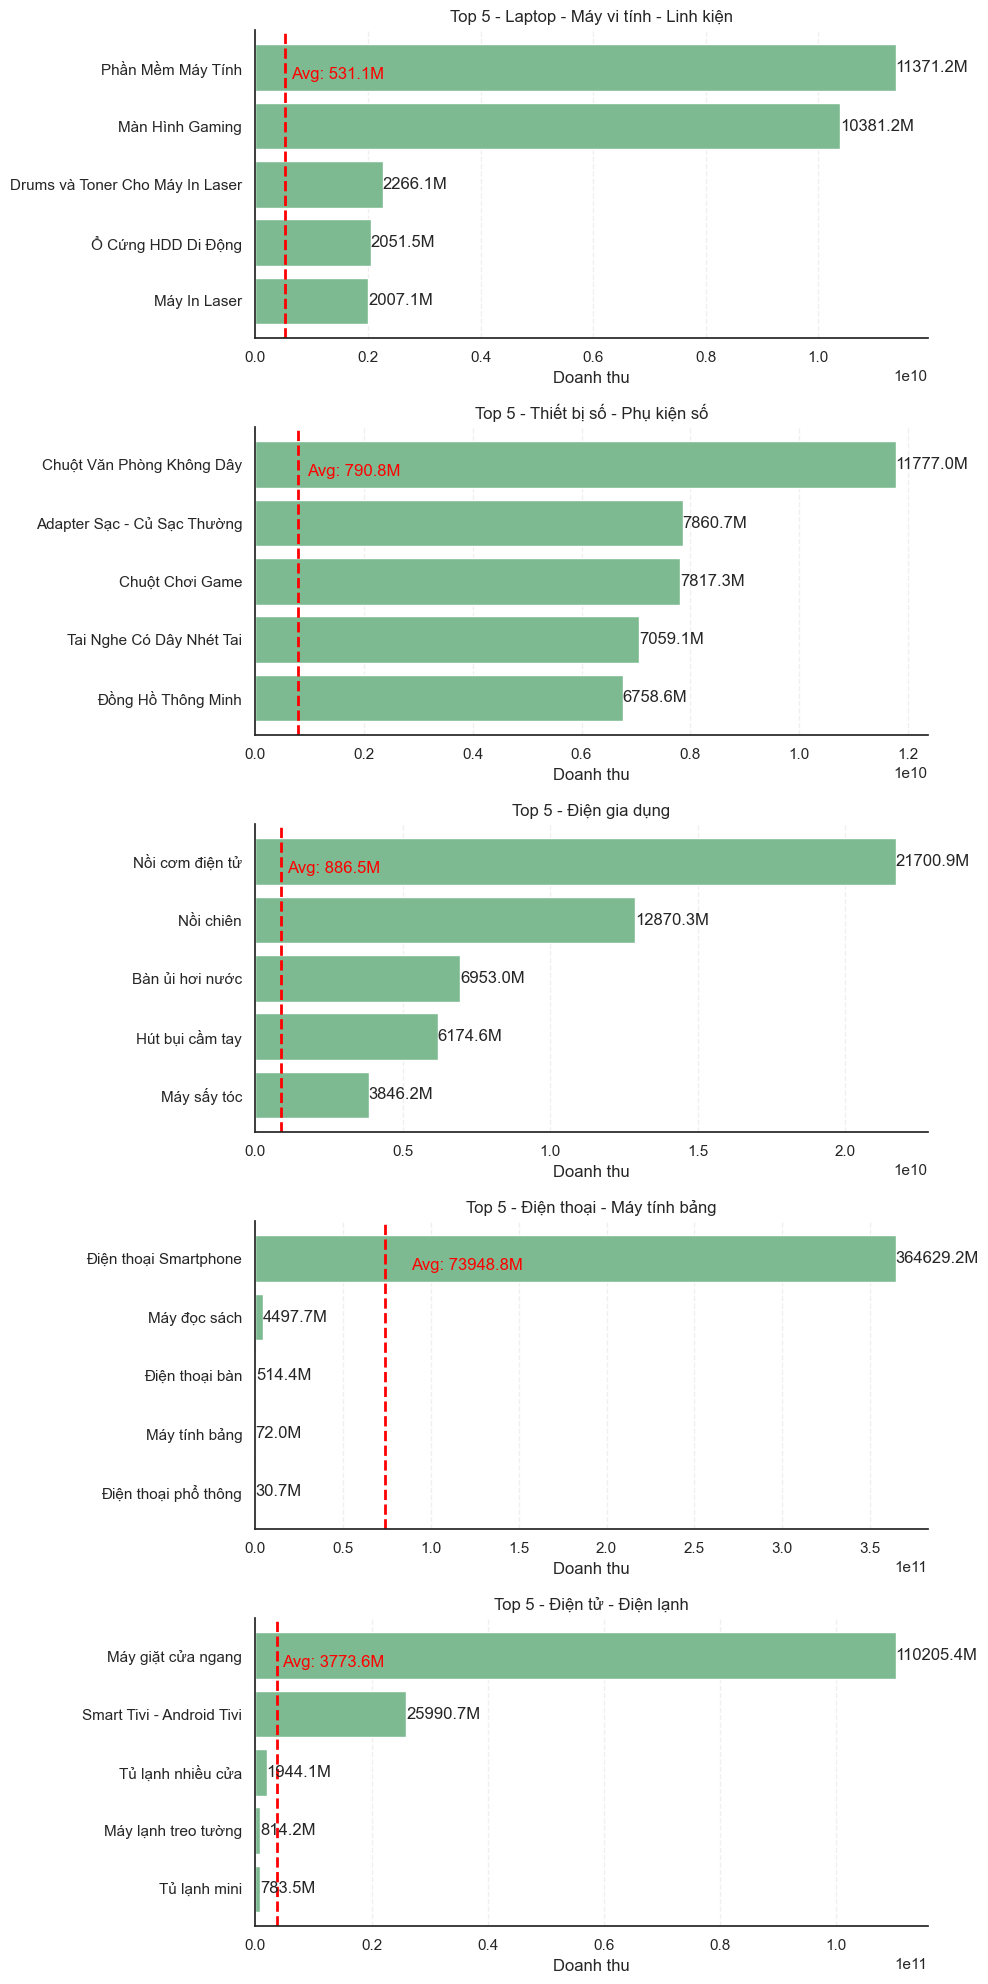

In [18]:
roots = top5_each_root["root_category_name"].unique()
n = len(roots)

fig, axes = plt.subplots(n, 1, figsize=(10, 4*n), squeeze=False)
axes = axes.flatten()

for i, root in enumerate(roots):
    data = top5_each_root[top5_each_root["root_category_name"] == root]
    
    axes[i].barh(data["category_name"], data["revenue"])
    axes[i].invert_yaxis()
    
    for j, v in enumerate(data["revenue"]):
        axes[i].text(v, j, f"{v/1e6:.1f}M", va='center')

    avg_val = avg_each_root[
        avg_each_root["root_category_name"] == root
    ]["avg_revenue"].values[0]

    axes[i].axvline(x=avg_val, color='red', linestyle='--', linewidth=2)
    axes[i].text(avg_val + avg_val * 0.2, 0.2, f"Avg: {avg_val/1e6:.1f}M", color='red')

    axes[i].set_title(f"Top 5 - {root}")
    axes[i].set_xlabel("Doanh thu")

    # ===== FIX SPINES bằng gca =====
    plt.sca(axes[i])   # set current axis
    ax = plt.gca()

    for spine in ["top", "right"]:
        ax.spines[spine].set_visible(False)
    # grid nhẹ
    ax.grid(axis='x', linestyle='--', alpha=0.3)


plt.tight_layout()
plt.show()

Quan sát:
- Tổng quan:
    - Tương tự như kết quả Top 5 doanh thu trên toàn bộ dataset, khi phân tích theo từng danh mục gốc, có thể thấy sự chênh lệch doanh thu giữa các category con vẫn rất rõ rệt.
    - Trong hầu hết các danh mục, giá trị trung bình nằm thấp hơn đáng kể so với nhóm Top 5, cho thấy phân phối doanh thu có xu hướng lệch phải. Điều này hàm ý rằng một số ít category đóng góp phần lớn doanh thu.
    - Đặc biệt, ở danh mục Điện thoại - Máy tính bảng, giá trị trung bình cao hơn so với các danh mục khác. Tuy nhiên, hiện tượng này nhiều khả năng bị chi phối bởi một category vượt trội (ví dụ: Điện thoại Smartphone), dẫn đến việc trung bình bị kéo lên.
    - Hiện tượng tương tự cũng xuất hiện ở Điện tử - Điện lạnh, khi Top 1 category có doanh thu vượt trội so với phần còn lại.
- Chi tiết từng lĩnh vực:
    - Laptop - Máy vi tính - Linh kiện: Phản ánh nhu cầu hiện tại của khách hàng với phần mềm máy tính, màn hình gaming lần lượt chiếm top1 và top2 trên Top 5 Doanh thu. Bên cạnh đó là ổ cứng HDD di động và máy in laser, phụ kiện máy in laser.
    - Thiết bị số - Phụ kiện số: Là danh mục có mức độ đồng đều cao nhất, tuy nhiên tổng doanh thu thấp hơn đáng kể so với các danh mục khác, cho thấy đây có thể là thị trường phân mảnh và cạnh tranh cao.
    - Điện gia dụng: Doanh thu trong Top 5 có sự chênh lệch nhất định, tuy nhiên nhiều category vẫn duy trì mức doanh thu cao và xuất hiện trong Top 5 toàn dataset, cho thấy đây là một ngành hàng có quy mô lớn và đóng góp đáng kể.
    - Điện thoại - Máy tính bảng: Category Smartphone vượt trội hoàn toàn so với các category còn lại, phản ánh mức độ tập trung doanh thu rất cao. Các category khác có xu hướng phục vụ các nhu cầu ngách và đóng góp doanh thu hạn chế hơn.
    - Điện tử - Điện lạnh: Category Máy giặt cửa ngang có doanh thu vượt trội, trong khi các category còn lại vẫn duy trì mức doanh thu tương đối tốt. Điều này cho thấy thị trường vừa có sản phẩm chủ lực, vừa có sự đa dạng nhất định.
    

Phân tích:
- Phân tích cho thấy trong hầu hết các danh mục gốc, doanh thu có xu hướng tập trung vào một số ít category, với Top 1 thường chiếm tỷ trọng lớn so với phần còn lại. Điều này phản ánh sự tồn tại của các *mặt hành chủ lực* trong từng ngành hàng.
- Tuy nhiên, mức độ tập trung này không đồng đều giữa các danh mục. Một số ngành có cấu trúc cân bằng hơn (phân phối đều), trong khi các ngành khác phụ thuộc mạnh vào một category duy nhất.
- Cần lưu ý rằng doanh thu chỉ phản ánh một phần hiệu quả kinh doanh. Việc đánh giá tiềm năng thực sự của category cần xem xét thêm các yếu tố khác như chi phí, lợi nhuận hoặc tốc độ tăng trưởng. Đây những yếu tố không có trong dataset hiện tại.

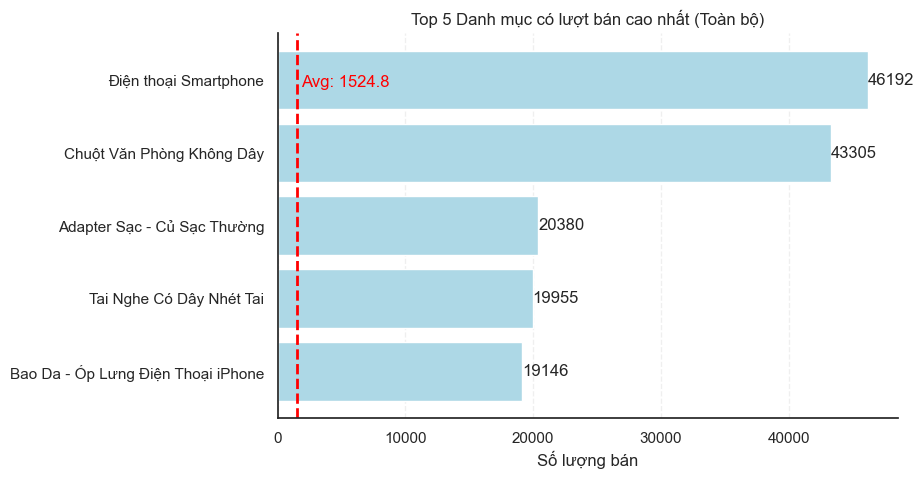

In [19]:
df_group_rank = (
    df_q1_product
    .groupby(["root_category_name", "category_name"])["sold_count"]
    .sum()
    .reset_index()
)

df_group_rank["rank"] = df_group_rank.groupby("root_category_name")["sold_count"] \
                          .rank(method="first", ascending=False)

top5_each_root = df_group_rank[df_group_rank["rank"] <= 5] \
                    .sort_values(["root_category_name", "rank"])

df_group_rank["pct_in_root"] = df_group_rank["sold_count"] / df_group_rank.groupby("root_category_name")["sold_count"].transform("sum")

#top 5 all
top5_all_rank = (
    df_group_rank
    .groupby("category_name")["sold_count"]
    .sum()
    .reset_index()
    .sort_values(by="sold_count", ascending=False)
    .head(5)
)

# average rank (all)
avg_all_rank = df_group_rank.groupby("category_name")["sold_count"].sum().mean()

# top5 each root
top5_each_root_rank = df_group_rank[df_group_rank["rank"] <= 5] \
                    .sort_values(["root_category_name", "rank"])

# average rank (each root)
avg_each_root_rank = (
    df_group_rank
    .groupby("root_category_name")["sold_count"]
    .mean()
    .reset_index(name="avg_sold_count")
)


plt.figure(figsize=(8,5))

plt.barh(top5_all_rank["category_name"], top5_all_rank["sold_count"], color='lightblue')
plt.gca().invert_yaxis()

for i, v in enumerate(top5_all_rank["sold_count"]):
    plt.text(v, i, f"{v}", va='center')

# vẽ đường average
plt.axvline(x=avg_all_rank, color='red', linestyle='--', linewidth=2)

# label cho avg
plt.text(avg_all_rank + avg_all_rank * 0.2, 0.1, f"Avg: {avg_all_rank:0.1f}", color='red')
ax = plt.gca()
for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)
plt.grid(axis='x', linestyle='--', alpha=0.3)

plt.title("Top 5 Danh mục có lượt bán cao nhất (Toàn bộ)")
plt.xlabel("Số lượng bán")

plt.show()

Quan sát:
- Điện thoại Smartphone giữ vị trí Top 1 về số lượng bán, dù thuộc phân khúc giá cao hơn đáng kể so với các sản phẩm còn lại. Điều này cho thấy mức độ phổ biến và nhu cầu ổn định của category này.
- 4/5 danh mục còn lại trong Top 5 lượt bán thuộc về Thiết bị số - Phụ kiện số. Cho thấy vai trò của các sản phẩm giá thấp và tiêu dùng thường xuyên trong việc thúc đẩy số lượng giao dịch.

Phân tích:
- Kết quả cho thấy sự khác biệt rõ ràng giữa hai góc nhìn: doanh thu và số lượng bán ra. Trong khi doanh thu thường bị chi phối bởi các sản phẩm giá cao, thì số lượng bán ra phản ánh trực tiếp nhu cầu thị trường.
- Các sản phẩm giá thấp có xu hướng xuất hiện nhiều hơn trong Top bán chạy do:
    - chi phí thấp -> giảm rào cản mua hàng trực tuyến(không sợ lừa đảo, rủi ro vận chuyển,...)
    - tần suất sử dụng cao -> nhu cầu lặp lại (Các sản phẩm này thường có tác dụng ngay tức thì, độ bền không cao hoặc một số sản phẩm được thiết kế để dùng trong giai đoạn ngắn)
- Tuy nhiên, sự xuất hiện của Điện thoại Smartphone ở Top 1 cho thấy đây là một category vừa có giá trị cao vừa có nhu cầu lớn. Đây là một insight khá mới với em trong thương mại điện tử.

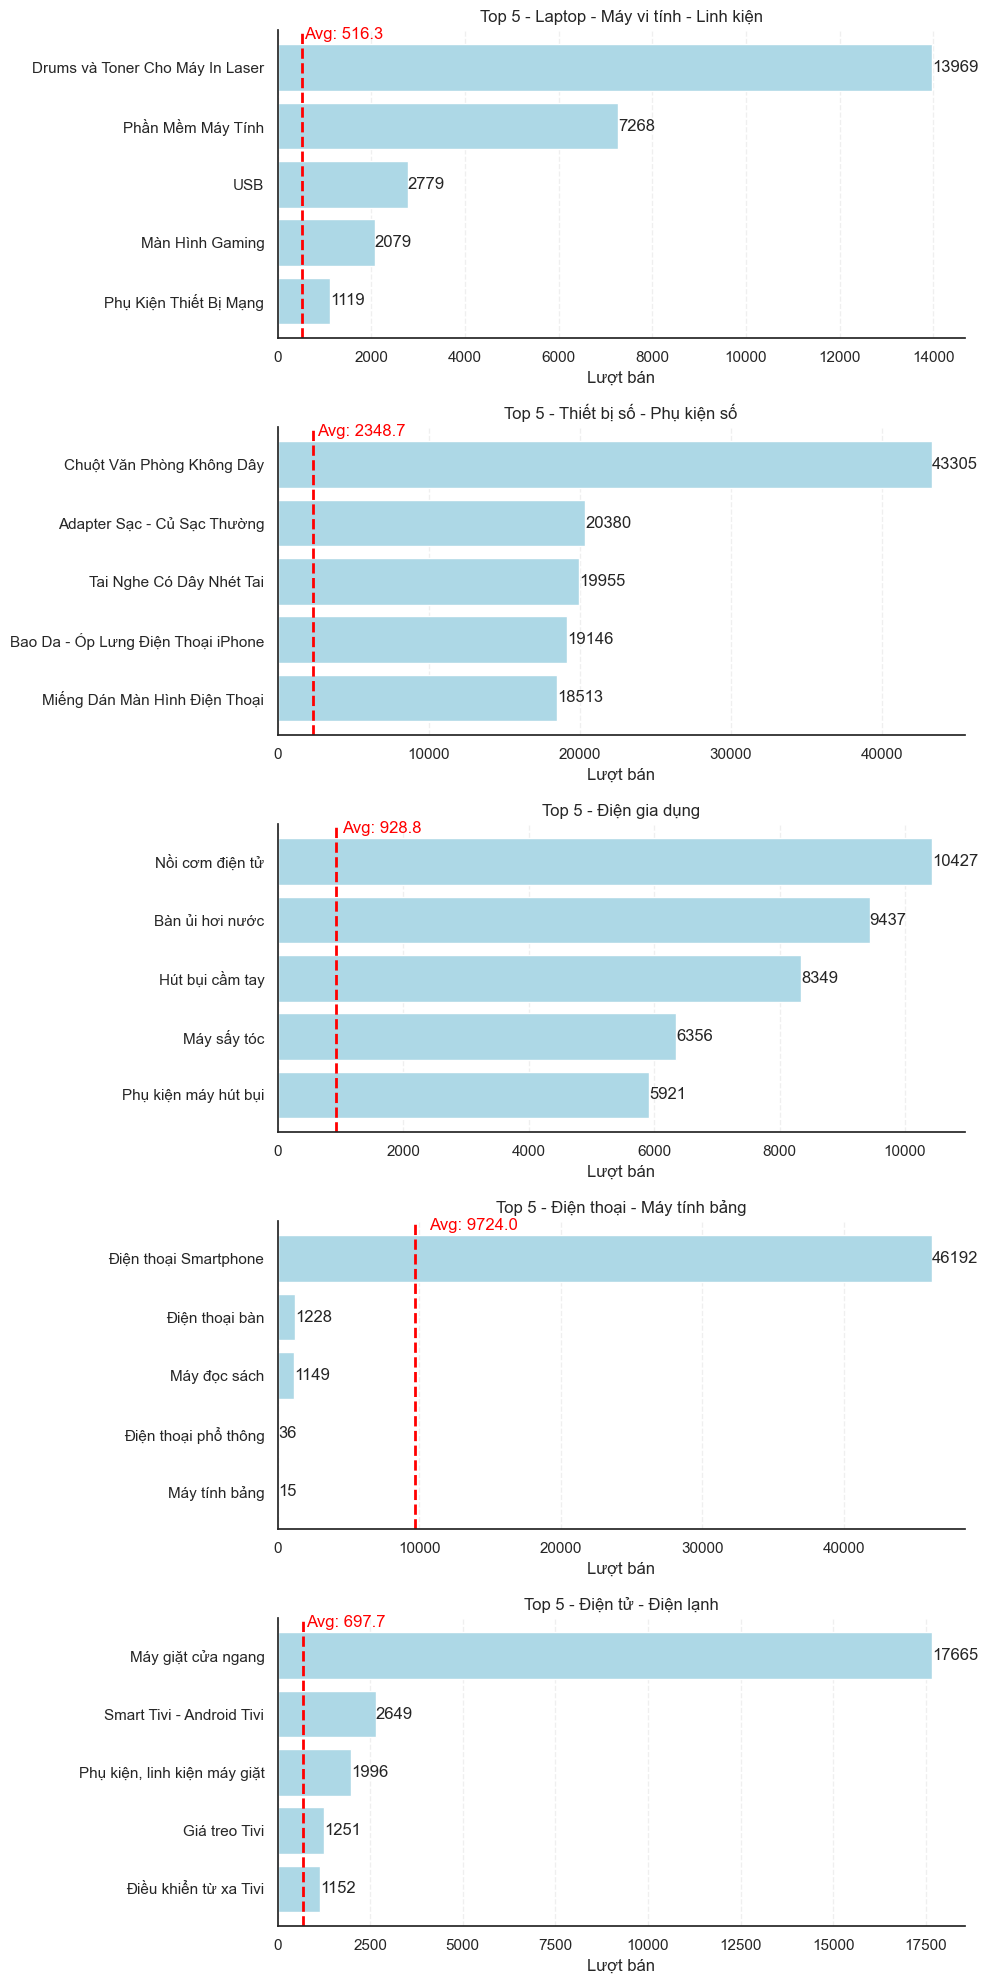

In [20]:
roots = top5_each_root_rank["root_category_name"].unique()
n = len(roots)

fig, axes = plt.subplots(n, 1, figsize=(10, 4*n), squeeze=False)
axes = axes.flatten()

    
for i, root in enumerate(roots):
    data = top5_each_root_rank[top5_each_root_rank["root_category_name"] == root]
    
    axes[i].barh(data["category_name"], data["sold_count"], color='lightblue')
    axes[i].invert_yaxis()
    
    for j, v in enumerate(data["sold_count"]):
        axes[i].text(v, j, f"{v}", va='center')

    axes[i].axvline(x=avg_each_root_rank[avg_each_root_rank["root_category_name"] == root]["avg_sold_count"].values[0],
                        color='red', linestyle='--', linewidth=2)
    axes[i].text(avg_each_root_rank[avg_each_root_rank["root_category_name"] == root]["avg_sold_count"].values[0] + avg_each_root_rank[avg_each_root_rank["root_category_name"] == root]["avg_sold_count"].values[0] * 0.1, -0.5,
                    f"Avg: {avg_each_root_rank[avg_each_root_rank['root_category_name'] == root]['avg_sold_count'].values[0]:0.1f}", color='red')

    plt.sca(axes[i])  
    ax = plt.gca()
    for spine in ["top", "right"]:
        ax.spines[spine].set_visible(False)
    plt.grid(axis='x', linestyle='--', alpha=0.3)
    axes[i].set_title(f"Top 5 - {root}")
    axes[i].set_xlabel("Lượt bán")

plt.tight_layout()
plt.show()

Quan sát:
- Tổng quan:
    - Phân phối theo số lượng bán ra nhìn chung tương đồng với kết quả theo doanh thu, tuy nhiên có xu hướng đồng đều hơn ở một số danh mục.
    - Đáng chú ý, mặc dù có sự chênh lệch lớn về giá, Điện thoại Smartphone vẫn duy trì mức độ áp đảo về số lượng bán trong cùng danh mục gốc, cho thấy nhu cầu mạnh và ổn định.
    - XNgoài ra, danh sách Top 5 xuất hiện nhiều hơn các sản phẩm thuộc phân khúc giá thấp như phụ kiện hoặc các mặt hàng tiêu dùng phổ biến, phản ánh sự dịch chuyển từ high-value sang high-volume products.
- Chi tiết từng danh mục:
    - Laptop - Máy vi tính - Linh kiện: Hai sản phẩm bổ trợ (phụ kiện) chiếm Top 1 và Top 2 với số lượng bán gần như tương đương (26,461 và 26,290), cho thấy nhu cầu ổn định và ít chênh lệch. Ngoài ra, xuất hiện thêm các sản phẩm liên quan đến mạng và USB so với bảng xếp hạng theo doanh thu.
    - Thiết bị số - Phụ kiện số: Tương tự kết quả theo doanh thu, nhưng ghi nhận thêm sự xuất hiện của các sản phẩm giá rẻ như bao da/ốp lưng và miếng dán màn hình.
    - Điện gia dụng: Không có sự thay đổi lớn, ngoại trừ nồi chiên nhường chỗ cho bàn ủi hơi nước, phụ kiện máy hút bụi xuất hiện.
    - Điện thoại - Máy tính bảng: Điện thoại Smartphone vẫn duy trì khoảng cách rất lớn so với các category còn lại. Các sản phẩm trong Top 5 phần lớn giữ nguyên so với bảng doanh thu, nhưng có sự thay đổi về thứ hạng.
    - Điện tử - điện lạnh: Các sản phẩm giá trị cao như tủ lạnh, máy lạnh (xuất hiện trong Top doanh thu) không còn nằm trong Top bán chạy, thay vào đó là các nhóm phụ kiện như linh kiện máy giặt, giá treo TV và điều khiển TV — những sản phẩm có giá thấp hơn nhưng nhu cầu cao hơn. Tuy nhiên, máy giặt cửa ngang và Smart Tivi - Android Tivi vẫn chiếm ưu thế


Phân tích:
- Phân tích cho thấy sự khác biệt rõ ràng giữa cấu trúc doanh thu và cấu trúc nhu cầu thị trường. Trong khi doanh thu tập trung vào các sản phẩm giá trị cao, thì số lượng bán ra lại nghiêng về các sản phẩm giá thấp và tiêu dùng thường xuyên.
- Sự xuất hiện ngày càng nhiều của các sản phẩm giá rẻ trong Top bán chạy cho thấy hành vi người tiêu dùng trên nền tảng thương mại điện tử ưu tiên các sản phẩm:
    - có giá thấp → giảm rào cản mua hàng
    - có tần suất sử dụng cao → nhu cầu lặp lại
    - ít rủi ro khi mua online
- Tuy nhiên, Điện thoại Smartphone là một trường hợp đặc biệt khi vừa duy trì được mức giá cao, vừa đạt số lượng bán lớn. Điều này cho thấy đây là category có khả năng cân bằng giữa high value và high demand, đóng vai trò quan trọng trong toàn bộ hệ sinh thái sản phẩm.
- Ngoài ra, sự thay thế của các sản phẩm giá trị cao bằng phụ kiện trong một số danh mục (như Điện tử - Điện lạnh) cho thấy doanh thu cao không đồng nghĩa với tần suất giao dịch cao. Các sản phẩm phụ trợ, dù giá trị thấp, lại đóng vai trò quan trọng trong việc duy trì lưu lượng giao dịch và mức độ hoạt động của nền tảng.

### Phân tích, kết luận - Câu hỏi 1

#### Phân tích đúc kết được:

1. Danh mục Điện thoại Smartphone thể hiện sự vượt trội rõ rệt về doanh thu so với tất cả các danh mục còn lại, cho thấy mức độ tập trung doanh thu cao trong một nhóm sản phẩm chủ đạo của sàn.
2. Các danh mục xếp sau đều có doanh thu thấp hơn đáng kể (dưới 1/3 so với danh mục dẫn đầu), phản ánh sự chênh lệch lớn về quy mô giữa các nhóm sản phẩm.
3. Nhóm Điện gia dụng chiếm tỷ trọng đáng kể trong top các danh mục có doanh thu cao, với 2/5 vị trí trong top 5, cho thấy nhu cầu mua sắm các sản phẩm phục vụ đời sống hàng ngày vẫn đóng vai trò quan trọng trên nền tảng.

#### Kết luận:
- Kết quả phân tích cho thấy cơ cấu doanh thu theo danh mục trên sàn Tiki mang tính tập trung cao, với sự dẫn dắt rõ rệt từ danh mục Điện thoại Smartphone. Đồng thời, sự hiện diện của các danh mục thuộc nhóm Điện gia dụng trong top đầu cho thấy nhu cầu tiêu dùng thiết yếu vẫn duy trì vai trò quan trọng bên cạnh các sản phẩm công nghệ.
- Từ câu hỏi đầu tiên này, em sẽ phân tích sâu hơn ở:
    - Phân tích yếu tố ảnh hưởng đến doanh thu, lượt bán của các danh mục này. Với cùng metric, ảnh hưởng của các yếu tố có giống nhau không? (Nhóm sẽ phân tích ở phần So sánh giữa các danh mục và ứng dụng ML để tăng độ khách quan, chính xác).
    - Trong từng danh mục đã phân tích, liệu có sản phẩm nào lại chiếm chủ đạo (như các Điện thoại Smartphone áp đảo các danh mục khác) không? Từ câu hỏi này, em sẽ đưa ra những phân tích từ tổng quát đến chi tiết các danh mục này

## 4. Câu hỏi 2: 
### Trong các danh mục có doanh thu cao đã xác định ở Câu 1, sự tăng trưởng này đến từ việc toàn bộ sản phẩm cùng đóng góp tương đối đồng đều, hay bị chi phối bởi một số ít sản phẩm nổi bật? NNếu tồn tại các sản phẩm này, đâu là những đặc điểm chung đứng sau hiệu suất vượt trội của chúng (trong giai đoạn 2021-2025)?

Lưu ý: 
- Do nhóm chia đều các khía cạnh phân tích để tận dụng triệt để thông tin từ một khía cạnh, nên ở câu hỏi này em xin phép chỉ khai thác về khía cạnh Category.

Triển khai:
- Em sẽ tiếp tục dùng dữ liệu từ Câu 1 để phân tích. Ở đây, em sẽ tập trung vào phân tích doanh thu.
- Để đánh giá tổng quan, em sẽ dùng boxplot trên dữ liệu chưa log-scale để đánh giá outlier.
- Sau đó, dùng boxplot đã log-scale kết hợp với bar chart thể hiện doanh thu của top 5 product có doanh thu cao nhất trong danh mục đó.

Giai đoạn phân tích: 2021 - 2025
- Để tiếp diễn câu chuyện đang kể ở Câu 1. 

In [21]:
df_q2_product = df_q1_product.copy()
df_q2_category = df_q1_category.copy()
df_q2_store = df_store.copy()
df_q2_review = df_review.copy()

df_review_agg = (
    df_q2_review
    .groupby("product_id")
    .agg({
        "rating": ["mean", "count"],
        "like_count": "mean"
    })
)

df_review_agg.columns = ["review_rating_avg", "review_count", "review_like_avg"]
df_review_agg = df_review_agg.reset_index()

df = df_q2_product.merge(
    df_review_agg, on="product_id", how="left", suffixes=("", "_drop")
)
df = df.merge(df_q2_store, on="store_id", how="left", suffixes=("", "_drop2"))
df = df[[c for c in df.columns if not c.endswith(("_drop", "_drop2"))]]

df.fillna({
    "review_rating_avg": 0,
    "review_count": 0,
    "review_like_avg": 0,
    "store_rating": 0,
    "follower_count": 0
}, inplace=True)

df_cat_product = (
    df
    .groupby(["category_name", "product_id", "product_name", "store_id"])
    .agg({
        "revenue": "sum",
        "sold_count": "sum"
    })
    .reset_index()
)

results = []

for cat, group in df_cat_product.groupby("category_name"):
    revenues = group["revenue"]
    
    total = revenues.sum()
    mean = revenues.mean()
    std = revenues.std()
    
    cv = std / mean if mean != 0 else 0
    
    sorted_rev = revenues.sort_values(ascending=False)
    
    top1_share = sorted_rev.iloc[0] / total
    top3_share = sorted_rev.head(3).sum() / total
    
    results.append({
        "category": cat,
        "num_products": len(group),
        "cv_revenue": cv,
        "top1_share": top1_share,
        "top3_share": top3_share
    })

df_analysis = pd.DataFrame(results)

df_analysis["dominant_flag"] = df_analysis["top1_share"] > 0.4

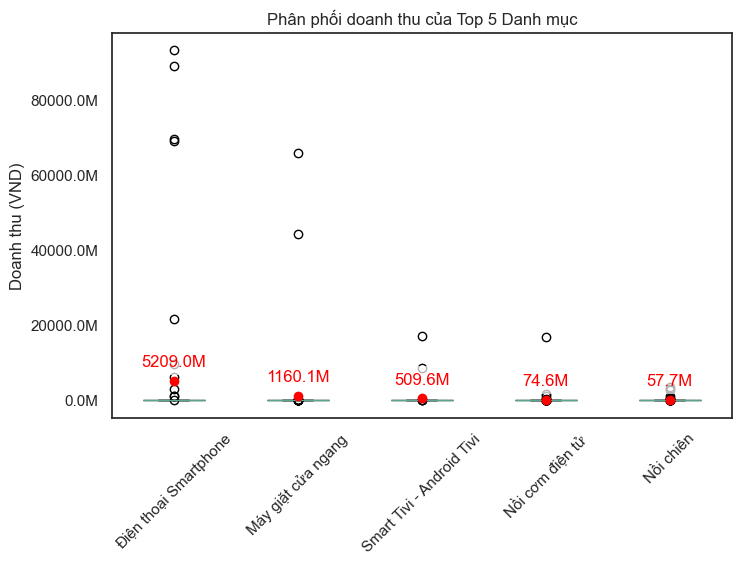

In [22]:
# TOP5 category
top_categories = (
    df_cat_product.groupby("category_name")["revenue"]
    .sum()
    .sort_values(ascending=False)
    .head(5)
    .index
)

data = [
    df_cat_product[df_cat_product["category_name"] == cat]["revenue"]
    for cat in top_categories
]


plt.figure(figsize=(8,5))

# boxplot
bp = plt.boxplot(data, labels=top_categories, patch_artist=True)

means = [np.mean(d) for d in data]
plt.scatter(range(1, len(means)+1), means, color='red', zorder=3)

y_min, y_max = plt.ylim()
offset = (y_max - y_min) * 0.03  

for i, m in enumerate(means):
    plt.text(i+1, m + offset, f"{m/1e6:.1f}M",
             color='red', ha='center', va='bottom',
             bbox=dict(facecolor='white', alpha=0.7, edgecolor='none'))


yticks = plt.gca().get_yticks()
plt.gca().set_yticklabels([f"{y/1e6:.1f}M" for y in yticks])

plt.title("Phân phối doanh thu của Top 5 Danh mục")
plt.ylabel("Doanh thu (VND)")

plt.xticks(rotation=45)

plt.show()

Quan sát:
- Phân phối doanh thu giữa các sản phẩm trong từng danh mục cho thấy mức độ tập trung không đồng đều, trong đó Điện thoại Smartphone nổi bật với nhiều outliers có giá trị rất cao (trên 80 tỷ đồng). Điều này cho thấy doanh thu của danh mục này không chỉ lớn về tổng thể mà còn phụ thuộc đáng kể vào một số ít sản phẩm vượt trội, góp phần lý giải vị thế dẫn đầu so với toàn thị trường.
- Tương tự, Máy giặt cửa ngang cũng thể hiện dấu hiệu tập trung doanh thu vào một số sản phẩm chủ lực, với sự xuất hiện của các outliers ở mức trên 40 và 60 tỷ đồng. Tuy nhiên, mức độ tập trung này thấp hơn so với nhóm điện thoại, cho thấy sự phân bổ doanh thu có phần cân bằng hơn.
- Đối với các danh mục như Smart Tivi - Android Tivi và Nồi cơm điện tử, sự xuất hiện của outliers ở mức khoảng 20 tỷ đồng cho thấy có tồn tại các sản phẩm nổi bật, nhưng quy mô đóng góp chưa đủ lớn để tạo ra sự chênh lệch mạnh trong toàn danh mục.
- Ngược lại, Nồi chiên có phân phối doanh thu ổn định hơn, với ít outliers và khoảng cách không quá xa so với median. Điều này phản ánh cấu trúc doanh thu phân tán hơn, không bị chi phối bởi một số ít sản phẩm, mà đến từ nhiều sản phẩm có mức đóng góp tương đối đồng đều.

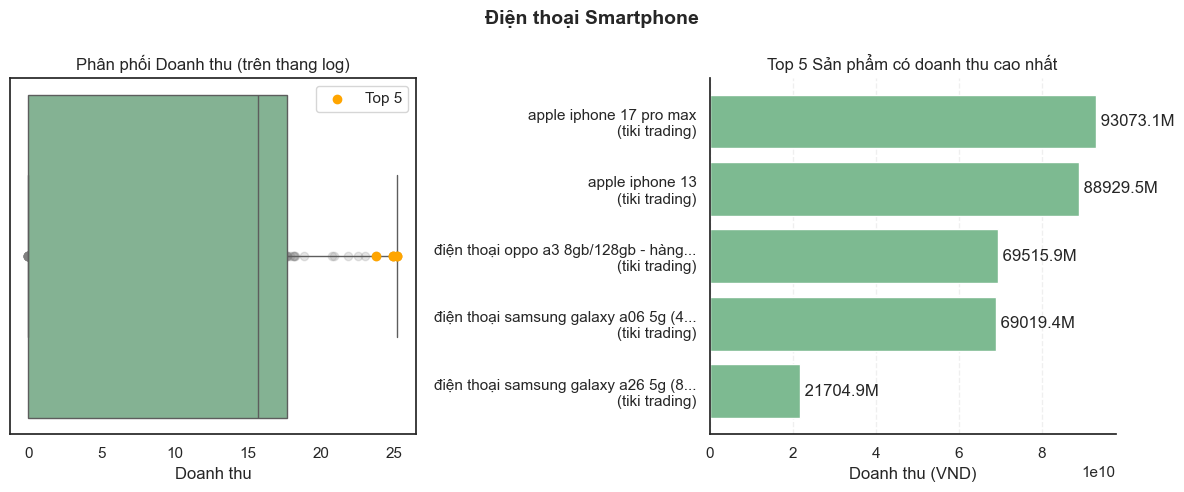

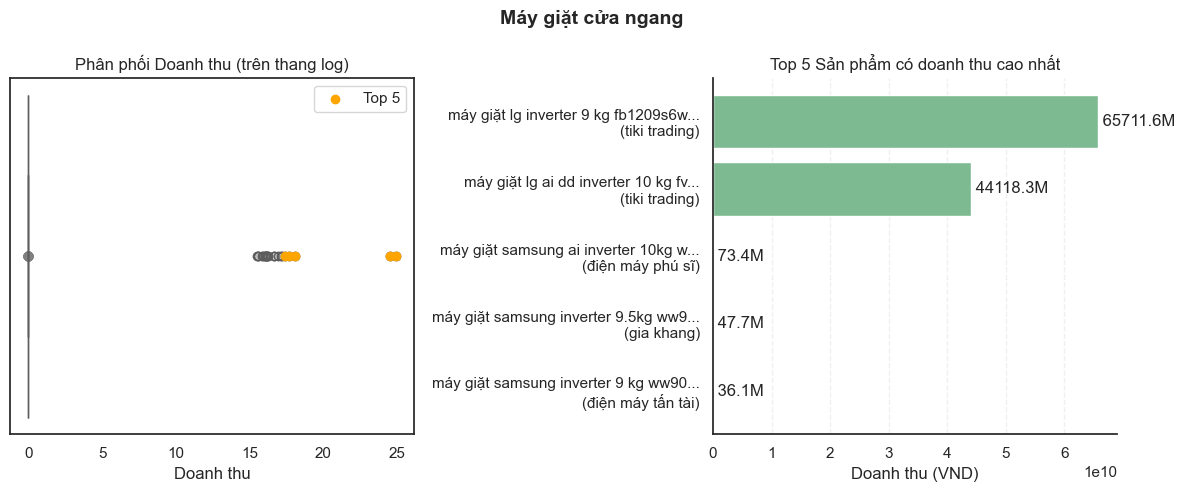

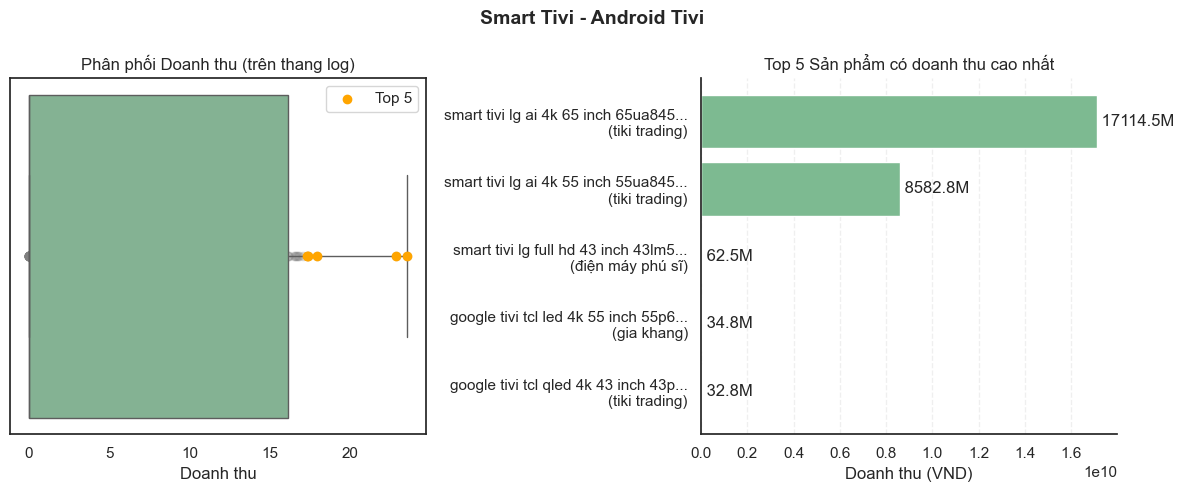

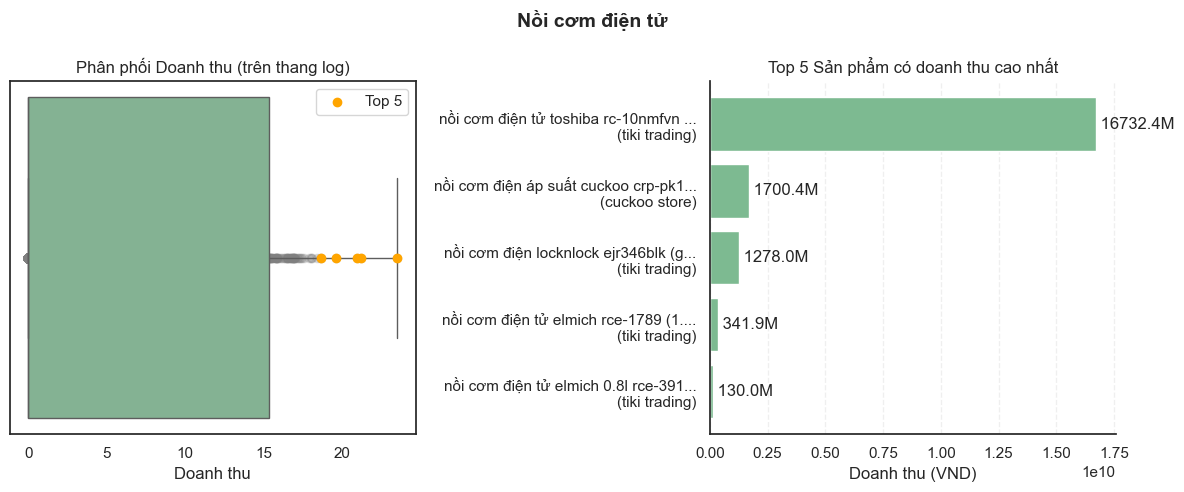

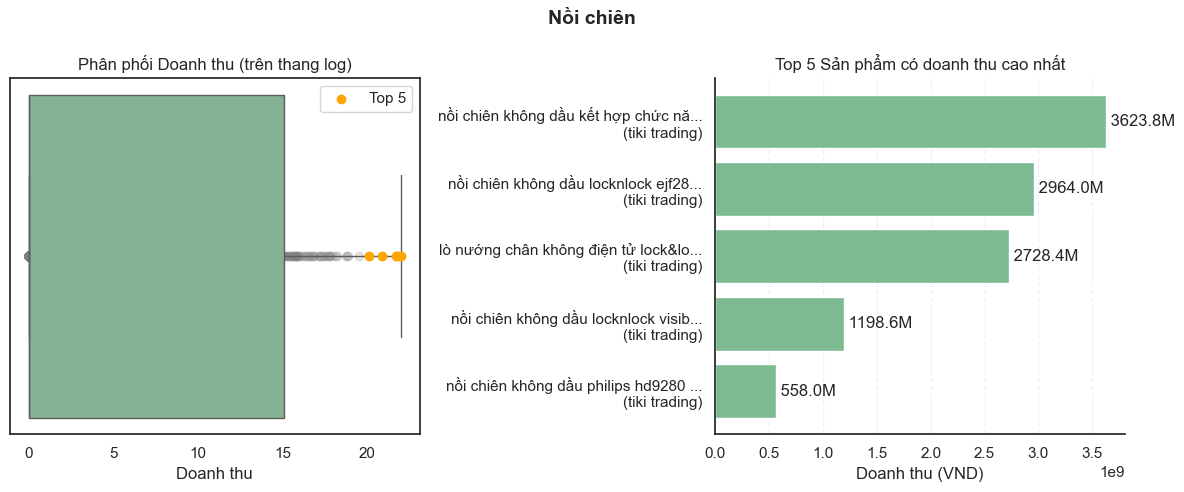

In [23]:
def truncate_text(text, max_len=35):
    return text if len(text) <= max_len else text[:max_len] + "..."

df_plot = df_cat_product.merge(
    df_store[["store_id", "store_name"]],
    on="store_id",
    how="left"
)

for cat in top_categories:
    df_sub = df_plot[df_plot["category_name"] == cat].copy()
    
    # log transform
    df_sub["log_revenue"] = np.log1p(df_sub["revenue"])
    
    # top 5
    top5 = df_sub.nlargest(5, "revenue").copy()
    top5["label"] = top5.apply(
        lambda x: f"{truncate_text(x['product_name'])}\n({x['store_name']})", axis=1
    )
    
    #visualize
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    
    #boxplt
    sns.boxplot(x=df_sub["log_revenue"], ax=axes[0])

    axes[0].scatter(df_sub["log_revenue"], np.zeros(len(df_sub)),
                    alpha=0.2, color="gray")

    axes[0].scatter(top5["log_revenue"], np.zeros(len(top5)),
                    color="orange", zorder=3, label="Top 5")

    axes[0].legend()
    axes[0].set_title("Phân phối Doanh thu (trên thang log)")
    axes[0].set_xlabel("Doanh thu")
    
    # barplt
    axes[1].barh(top5["label"], top5["revenue"])
    axes[1].invert_yaxis()
    axes[1].set_title("Top 5 Sản phẩm có doanh thu cao nhất")
    axes[1].set_xlabel("Doanh thu (VND)")
    plt.sca(axes[1])
    plt.grid(axis='x', linestyle='--', alpha=0.3)
    ax = plt.gca()
    for spine in ["top", "right"]:
        ax.spines[spine].set_visible(False)

    for i, v in enumerate(top5["revenue"]):
        axes[1].text(v, i, f" {v/1e6:.1f}M", va='center')
    
    plt.suptitle(f"{cat}", fontsize=14, fontweight='bold')
    
    plt.tight_layout()
    plt.show()

Quan sát:

- Một đặc điểm nổi bật là sự xuất hiện xuyên suốt của Tiki Trading trong hầu hết các danh mục, với mức doanh thu vượt trội so với các cửa hàng còn lại. Đây là gian hàng chính thức của nền tảng, và trong nhiều trường hợp, đóng vai trò chi phối doanh thu của toàn bộ danh mục.
    
- Sau khi áp dụng log-scale để quan sát rõ hơn phân phối doanh thu, có thể nhận thấy sự khác biệt đáng kể giữa các danh mục: 
    - Điện thoại Smartphone: Phân phối tương đối đầy đủ với các tứ phân vị rõ ràng, median nằm khoảng mức trung bình trong khi tồn tại các outliers cao hơn đáng kể.
    - Máy giặt cửa ngang: Phân phối bị lệch mạnh, các giá trị tập trung sát mức thấp (gần 0 trên log-scale), trong khi top sản phẩm tạo thành các outliers tách biệt hoàn toàn.
    - Smart Tivi - Android Tivi, Nồi cơm điện tử, Nồi chiên: Có thể quan sát được thân boxplot nhưng median không rõ ràng, cho thấy phần lớn sản phẩm tập trung ở mức thấp, trong khi một số ít sản phẩm top kéo phân phối lên cao.
- Chi tiết cho từng danh mục:
    - Điện thoại Smartphone: Các sản phẩm doanh thu cao nhất (iPhone, Oppo, Samsung Galaxy) đều thuộc Tiki Trading.
    - Máy giặt cửa ngang: Hai sản phẩm dẫn đầu (LG) thuộc Tiki Trading, vượt trội hoàn toàn so với các sản phẩm Samsung từ các nhà bán tư nhân.
    - Smart Tivi - Android Tivi: Tiki Trading chiếm phần lớn các vị trí top, xen kẽ một số sản phẩm từ nhà bán tư nhân nhưng không tạo được sự cạnh tranh đáng kể.
    - Nồi cơm điện tử: Sản phẩm dẫn đầu thuộc Tiki Trading, vị trí thứ hai thuộc nhà bán tư nhân Cuckoo.
    - Nồi chiên: Tiki Trading chiếm toàn bộ top 5 sản phẩm.

Phân tích:
- Phân tích cho thấy cấu trúc doanh thu trong nhiều danh mục mang tính tập trung cao theo nhà bán, trong đó Tiki Trading đóng vai trò trung tâm. Không chỉ xuất hiện rộng khắp, gian hàng này còn chiếm lĩnh các vị trí dẫn đầu, qua đó ảnh hưởng trực tiếp đến phân phối doanh thu và làm gia tăng mức độ chênh lệch giữa các sản phẩm.
- Sự lệch phân phối quan sát được ở nhiều danh mục không chỉ đến từ đặc tính sản phẩm, mà còn phản ánh sự thống trị của một nhà bán lớn, khiến phần lớn các sản phẩm còn lại bị “nén” ở vùng doanh thu thấp. Điều này đặc biệt rõ ở các danh mục như Máy giặt cửa ngang hay Nồi chiên, nơi khoảng cách giữa nhóm dẫn đầu và phần còn lại là rất lớn.
- Đồng thời, việc Tiki Trading liên tục chiếm ưu thế ở các sản phẩm top cho thấy vai trò của các yếu tố như uy tín thương hiệu, chính sách bảo vệ người mua, và lợi thế nền tảng trong việc thúc đẩy hành vi mua sắm. Những yếu tố này có thể tạo ra lợi thế cạnh tranh đáng kể so với các nhà bán tư nhân, ngay cả khi sản phẩm tương đồng.
- Tuy nhiên, sự tồn tại của một số nhà bán tư nhân (ví dụ như Cuckoo trong danh mục nồi cơm điện tử) ở các vị trí cao cho thấy vẫn tồn tại cơ hội cạnh tranh, đặc biệt khi nhà bán có lợi thế về thương hiệu hoặc chuyên môn sản phẩm.

### Phân tích, kết luận - Câu hỏi 2

#### Phân tích đúc kết:

1. Doanh thu trong nhiều danh mục có sự phân bố không đồng đều, với phần lớn sản phẩm tập trung ở mức thấp và chỉ một số ít sản phẩm tạo ra doanh thu vượt trội.
2. Các sản phẩm dẫn đầu thuộc về cùng một nhà bán (Tiki Trading), cho thấy sự tập trung doanh thu không chỉ theo sản phẩm mà còn theo nhà bán.
3. Mức độ phân tán khác nhau giữa các danh mục: một số danh mục như Điện thoại Smartphone tuy có nhiều outlier vượt trội nhưng khi log-scale lại có phân phối rõ ràng hơn, trong khi các danh mục khác như Máy giặt cửa ngang hay Nồi chiên thể hiện sự lệch mạnh với khoảng cách lớn giữa nhóm dẫn đầu và phần còn lại.

#### Kết luận:
- Kết quả phân tích cho thấy doanh thu của các sản phẩm trong cùng một danh mục không tăng trưởng đồng đều, mà có xu hướng bị chi phối bởi một số ít sản phẩm chủ lực. Điều này đặc biệt rõ ở các danh mục có phân phối lệch, nơi phần lớn sản phẩm đóng góp rất nhỏ so với nhóm dẫn đầu.
- Bên cạnh đó, sự tập trung doanh thu còn gắn liền với một số nhà bán lớn, tiêu biểu là Tiki Trading, cho thấy hiệu quả kinh doanh không chỉ phụ thuộc vào đặc tính sản phẩm mà còn chịu ảnh hưởng mạnh từ uy tín và vị thế của nhà bán trên nền tảng.
- Do đó, có thể kết luận rằng trong phần lớn các danh mục, hiệu suất doanh thu không phản ánh sức mạnh đồng đều của toàn bộ sản phẩm, mà chủ yếu được dẫn dắt bởi một nhóm nhỏ các sản phẩm nổi bật. Điều này hàm ý rằng việc đánh giá tiềm năng của một danh mục cần đi sâu vào cấu trúc bên trong, thay vì chỉ dựa trên tổng doanh thu.


---
## KẾT LUẬN CUỐI CÙNG

Sau hai câu hỏi mục tiêu phân tích, chúng ta đã đi từ việc xác định các danh mục tiềm năng đến việc làm rõ cấu trúc và động lực tăng trưởng bên trong từng danh mục.

- Giai đoạn 2021–2025 đánh dấu nhiều biến động và đổi mới trong nền kinh tế nói chung và lĩnh vực thương mại điện tử nói riêng. Dựa trên kết quả phân tích ở Câu hỏi 1, có thể nhận thấy thị trường thương mại điện tử. Đặc biệt nền tảng Tiki đã mở rộng từ buôn bán đồ gia dụng, đồ chơi và sách báo sang nhiều lĩnh vực mới với sự tham gia của nhiều thành phần khác nhau. Không chỉ các nhà bán tư nhân, mà bản thân nền tảng thông qua Tiki Trading cũng đang mở rộng phạm vi hoạt động sang nhiều danh mục sản phẩm, góp phần gia tăng mức độ cạnh tranh trên thị trường.

- Trong bối cảnh đó, dữ liệu cho thấy vẫn tồn tại nhiều hướng đi và *ngách* tiềm năng cho các nhà bán thử sức. Đáng chú ý, các nhóm như Thiết bị số - Phụ kiện số và Điện gia dụng không chỉ có nhu cầu ổn định mà còn thể hiện mức độ phân bổ doanh thu tương đối cân bằng hơn ở cấp độ danh mục con. Điều này tạo điều kiện thuận lợi cho các nhà bán tư nhân, đặc biệt là những đơn vị mới tham gia, có thể khai thác thị trường, đồng thời mở rộng dần danh mục sản phẩm dựa trên nền tảng nhu cầu sẵn có.

- Tuy nhiên, khi chuyển sang góc nhìn của các doanh nghiệp quy mô lớn, bức tranh cạnh tranh trở nên phức tạp hơn. Phân tích chi tiết cho thấy các sản phẩm và danh mục dẫn đầu về doanh thu phần lớn thuộc về Tiki Trading hoặc các doanh nghiệp đã xây dựng được vị thế vững chắc trên nền tảng. Điều này phản ánh sự tồn tại của các rào cản cạnh tranh nhất định, đòi hỏi doanh nghiệp không chỉ dựa vào sản phẩm mà còn cần tận dụng các lợi thế về thương hiệu, vận hành và chiến lược phân phối để có thể cạnh tranh hiệu quả.